In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
payment_df = pd.read_csv(r'C:\Users\aalgo\OneDrive\Desktop\Olist_Real_Data_EDA_Practice\Data\olist_order_payments_dataset.csv')

In [4]:
payment_df.shape

(103886, 5)

In [5]:
payment_df.size

519430

In [6]:
payment_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [7]:
payment_df.head()
payment_df.sample(5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
35566,1cb44c843df038496648b84a904aafa6,1,credit_card,1,12.06
19943,1b4e5194ba21a82ca345b9c27211b00d,1,credit_card,4,129.78
84988,f013cb01232922e713ffadcfa3b52368,1,credit_card,1,65.00
83500,650e96bb8f069e30f346534aa42860a7,1,credit_card,2,47.93
50951,7b1cf9f880b0f7eba111c5342dd2fba9,1,credit_card,4,105.28


* Q6. Calculate the standard deviation and variance of payment_value from order_payments. What does the std tell you about price spread?Markdo

In [8]:
payment = payment_df['payment_value'].to_numpy()
type(payment)

numpy.ndarray

In [9]:
payment.std()

np.float64(217.49301707022238)

In [10]:
payment.var()

np.float64(47303.21247430804)

* Q7. Find the 25th, 50th, 75th, and 90th percentiles of the price column using np.percentile()

In [11]:
df = pd.read_csv(r'C:\Users\aalgo\OneDrive\Desktop\Olist_Real_Data_EDA_Practice\Data\olist_order_items_dataset.csv')

In [12]:
price = df['price'].to_numpy()

In [13]:
type(price)

numpy.ndarray

In [14]:
print(np.percentile(price,25))
print(np.percentile(price,50))
print(np.percentile(price,75))
print(np.percentile(price,90))


39.9
74.99
134.9
229.8


* Q8. Normalize the price column to a 0–1 scale using min-max normalization: (x - min) / (max - min).
Print the first 10 normalized values.
💡 Hint: NumPy makes this a one-liner with broadcasting

In [15]:
#normalize with (x - min) / (max - min)
norm = (price-price.min()) / (price.max() - price.min())

In [17]:
norm[:10]

array([0.00862024, 0.03549817, 0.02942465, 0.00180275, 0.0295583 ,
       0.00312586, 0.00282886, 0.12015622, 0.02154689, 0.00789112])

* Q9. Compute the correlation coefficient between price and freight_value using np.corrcoef(). Is there a
relationship?

In [18]:
#create a freight np.array here
freight = df['freight_value'].to_numpy()

In [19]:
#find correlation between freight_value and price
np.corrcoef(price,freight)

array([[1.        , 0.41420431],
       [0.41420431, 1.        ]])

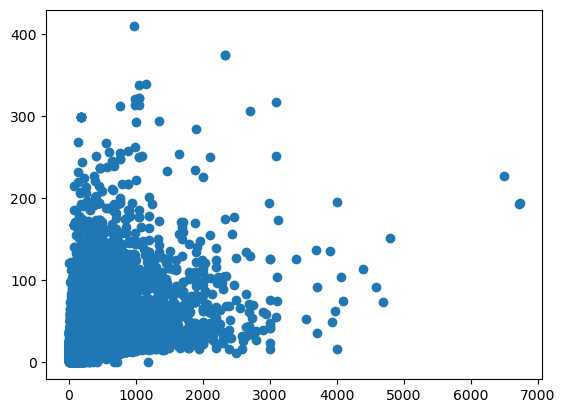

In [20]:
plt.plot(price,freight,'o')
plt.show()

* Q10. Identify outliers in payment_value: values more than 3 standard deviations from the mean. How
many outliers exist?
💡 Hint: Z-score method: (x - mean) / std > 3

In [21]:
# find outlier using Z score methode in payment_value array
outlier = (payment - payment.mean()) / payment.std() > 3

In [22]:
outlier.sum()

np.int64(1803)